# 17 - Fairness Mitigation, Not Just Diagnosis (Albania 2022)

The audit (notebook 07) found the screener **over-flags the poorest students**: at a single 0.5 threshold the bottom SES quintile carries a far higher false-positive rate than the top. Diagnosis is not enough - this notebook *fixes* it, post-hoc, with **no retraining** (`scripts/run_fairness_mitigation.py`): group-specific decision thresholds (Hardt et al. 2016) applied to frozen out-of-fold predictions, equalising the weighted FPR across quintiles, and the fairness-utility trade-off that buys.

In [1]:
import sys, os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # project root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
import json
from src.visualization.style import apply_publication_style, PALETTE
apply_publication_style()
S = json.load(open('../outputs/results/fairness_mitigation_summary.json'))
fr = pd.read_csv('../outputs/results/fairness_mitigation_frontier_ses.csv')
print('target FPR', S['target_fpr'], '| per-group thresholds', S['group_thresholds'])

target FPR 0.421 | per-group thresholds {'1.0': 0.803, '2.0': 0.581, '3.0': 0.576, '4.0': 0.493, '5.0': 0.266}


## 1. The harm: a single threshold over-flags the poorest

Weighted false-positive rate by SES quintile (1 = poorest) at the 0.5 threshold, and after equalising FPR with group-specific thresholds.

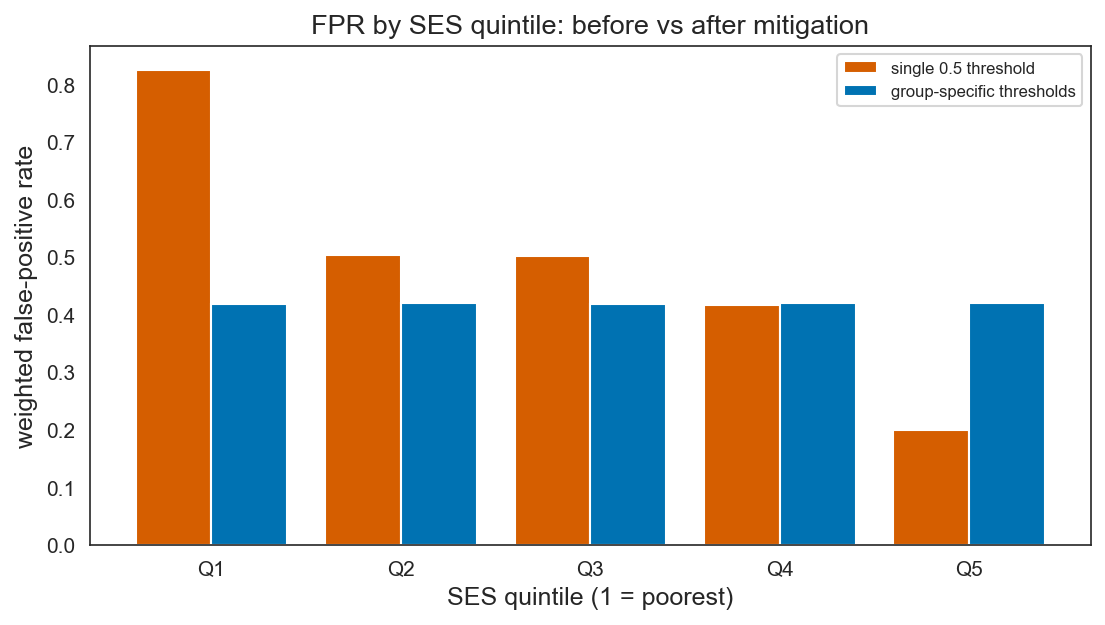

FPR gap 0.626 -> 0.003


In [3]:
b = S['baseline_fpr_by_group']; m = S['mitigated_fpr_by_group']
q = sorted(b, key=float); x = np.arange(len(q))
fig, ax = plt.subplots(figsize=(7.5,4.3))
ax.bar(x-0.2, [b[k] for k in q], 0.4, label='single 0.5 threshold', color=PALETTE['vermilion'])
ax.bar(x+0.2, [m[k] for k in q], 0.4, label='group-specific thresholds', color=PALETTE['blue'])
ax.set_xticks(x); ax.set_xticklabels([f'Q{int(float(k))}' for k in q])
ax.set_xlabel('SES quintile (1 = poorest)'); ax.set_ylabel('weighted false-positive rate')
ax.set_title('FPR by SES quintile: before vs after mitigation'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"FPR gap {S['baseline']['fpr_gap']:.3f} -> {S['mitigated']['fpr_gap']:.3f}")

**Reading:** at a single 0.5 threshold the poorest quintile is flagged with an FPR of ~0.83 versus ~0.20 for the richest - an equalized-odds gap of **0.63**. Because the model reads socioeconomic composition, a blanket threshold turns *being poor* into *being flagged*. Group-specific thresholds flatten every quintile's FPR to ~0.42, collapsing the gap to **0.003** - the disparity was an artefact of the operating point, and it is removable without touching the model.

## 2. What it costs: the fairness-utility trade-off

Equalising FPR is not free - it changes who gets caught. The frontier sweeps the common target FPR; each point compares group-specific thresholds against a single global threshold matched to the same overall selection rate.

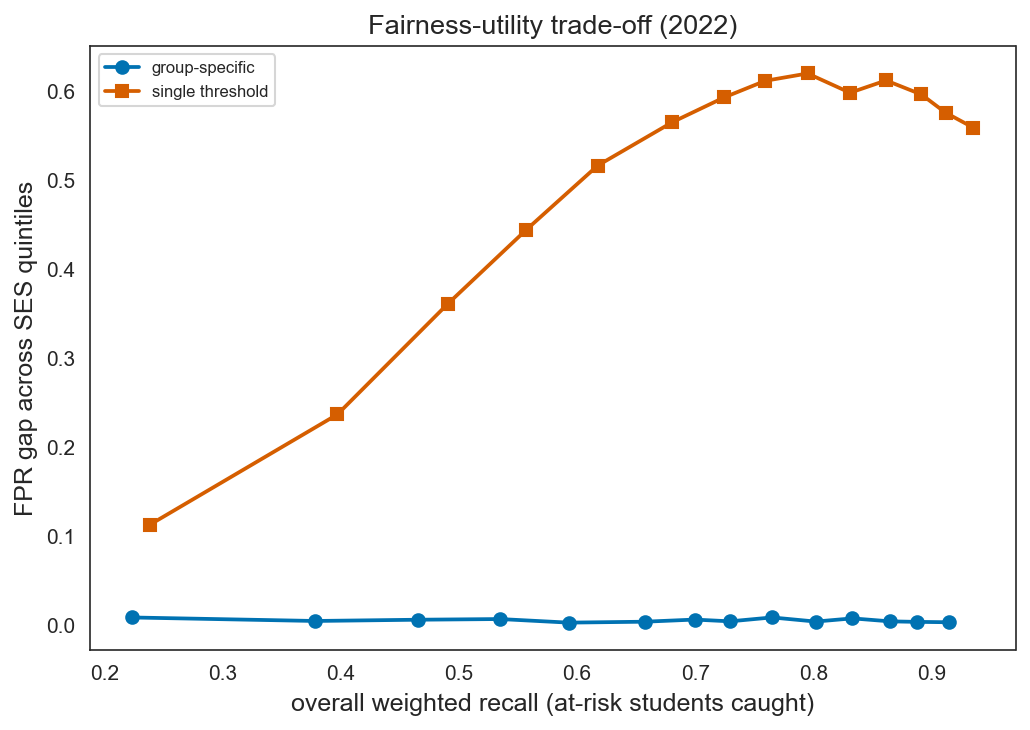

At the equal-FPR operating point: recall 0.808 -> 0.746, accuracy 0.751 -> 0.705


In [4]:
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(fr.grp_recall, fr.grp_fpr_gap, '-o', color=PALETTE['blue'], label='group-specific')
ax.plot(fr.single_recall, fr.single_fpr_gap, '-s', color=PALETTE['vermilion'], label='single threshold')
ax.set_xlabel('overall weighted recall (at-risk students caught)')
ax.set_ylabel('FPR gap across SES quintiles')
ax.set_title('Fairness-utility trade-off (2022)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"At the equal-FPR operating point: recall {S['baseline']['overall_recall']:.3f} "
      f"-> {S['mitigated']['overall_recall']:.3f}, accuracy "
      f"{S['baseline']['overall_accuracy']:.3f} -> {S['mitigated']['overall_accuracy']:.3f}")

**Reading:** at matched utility the group-specific curve sits **far below** the single-threshold curve - for any given recall it delivers a much smaller FPR gap, so per-group thresholds dominate a blanket one. The equity is not free: equalising FPR moves overall recall from ~0.81 to ~0.75 (about 6 pp fewer at-risk students caught), because much of the poorest quintile's high FPR came bundled with genuinely catching its at-risk students. That trade - a small recall cost for near-zero disparity - is a policy choice the frontier makes explicit rather than hiding in a default 0.5.

## Conclusions & Interpretation

- **The disparity is fixable post-hoc.** Group-specific thresholds cut the SES false-positive gap from **0.63 to ~0.00** with no retraining, operating only on frozen out-of-fold predictions.
- **Per-group thresholds dominate a single threshold** on the fairness-utility frontier - a strictly better operating curve for equalized odds.
- **Equity has a price, and we name it:** ~6 pp of overall recall. Whether that trade is worth it is a policy decision, now explicit.
- **Caveat:** applying different thresholds by socioeconomic group is itself an ethical and legal choice (disparate treatment to reduce disparate impact). We present it as a quantified option, not a default - the honest counterpart to the audit's diagnosis.